In [1]:
from dataclasses import dataclass
from typing_extensions import Self
from typing import Callable
import numpy as np
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from skimage.metrics import structural_similarity as ssim
from torchvision import transforms
from torch.utils.data import DataLoader
from torch import nn
import matplotlib.pyplot as plt
import torch.optim as optim
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_sequence
from tqdm import tqdm
import torch

# %matplotlib widget

from typing import Optional
import matplotlib.pyplot as plt
import torch

from pileup_ml.detectors.pixels import PixelDetector, PixelModule
from pileup_ml.pixels.hits import PixelDigiEvent
from pileup_ml.pixels.patches import (
    PixelModulePatches, PixelEventPatches, _PixelEventGrid,
    event_hits_to_patches, module_patches_to_hits, event_patches_to_hits)
from pileup_ml.compression.metrics import compare_matching_hits, compare_hit_presence

from pileup_ml.compression.base import CompressedPixelEvent
from numpy import cov, trace, iscomplexobj
from scipy.linalg import sqrtm
from torch.utils.data import random_split
from torchmetrics.regression import MeanSquaredError
from matplotlib.gridspec import GridSpec

In [2]:
# References
# https://datatas.com/how-to-use-variational-autoencoders-for-large-scale-data-compression/

In [3]:
# Task:
# Create plot with train loss, test loss, valid loss
# Plots with different betas
# Check what error curves are good for VAE
# Plot before and after plots

In [4]:
SELECTED_EVENTS = 1
EVENT_COUNT = 1
PATCH_SIZE = 8
BITS_HIT = 25

In [5]:
def show_image(events: np.array) -> None:
    image_plot = events.to_images()[0][1]
    plt.imshow(image_plot, cmap='gist_yarg', origin='lower')
    plt.show()
    
def _tensor_to_numpy(values: torch.Tensor) -> np.array:
    return values.cpu().detach().numpy()

def plot_patch(patch: np.array, title: str) -> None:
    plt.imshow(patch, cmap='gist_yarg', origin='lower')
    plt.title(title)
    plt.show()
    
def _get_encoded_patch_bits(encoded_size,
                           patch_size,
                           module_rows=160,
                           module_cols=416):
    
    encoded_width, encoded_height, num_embeddings = encoded_size
    # print(encoded_width, encoded_height, np.log2(num_embeddings))
    vq_bits = encoded_width * encoded_height * np.log2(num_embeddings)
    
    # Patch address bits
    bits_patch_row = np.ceil(np.log2(np.ceil(module_rows / patch_size)))
    bits_patch_col = np.ceil(np.log2(np.ceil(module_cols / patch_size)))
    total = bits_patch_row + bits_patch_col + vq_bits
    
    # 267 % 256 = 11
    return total.astype(np.uint8)

def _get_total_hit_bits(total_hits: int) -> int:
    
    # Patch address bits
    return total_hits * BITS_HIT

def _get_total_patch_bits(patch_amount: int, encoded_patch_size: tuple, patch_size: int) -> int:
    encoded_patch_bits = _get_encoded_patch_bits(encoded_patch_size, patch_size)
    return np.uint64(patch_amount * encoded_patch_bits)

def _get_compression_ratio(n_hits_total: int, patch_amount: int, encoded_patch_size: tuple, patch_size: int) -> float:
    total_bits = _get_total_hit_bits(n_hits_total)
    
    total_patch_bits = _get_total_patch_bits(
        patch_amount, 
        encoded_patch_size, 
        patch_size
    )
    return total_bits / total_patch_bits

def _get_patch_count(event: PixelDigiEvent) -> int:
    event_patches_adcs_flat = event_hits_to_patches(event, patch_size=PATCH_SIZE).as_array()
    # event_patches_adcs = [
    #     event_patch_flat.reshape(PATCH_SIZE, PATCH_SIZE)
    #     for event_patch_flat in event_patches_adcs_flat
    # ]
    return len(event_patches_adcs_flat)
    
# helper function
def _display_gradients(model: object) -> None:
    print("Showing model gradients")
    for name, param in model.named_parameters():
        if param.grad is not None:
            print(name, param.grad.norm().item())
            
def plot_metric_results(
    y_values: list[float], 
    x_values: int, 
    y_title: str, 
    title: str,
    x_label: str,
    marker: str=None
) -> None:
    print(title + " values over epochs")
    plt.style.use('fivethirtyeight')
    plt.figure(figsize=(8, 5))
    plt.plot(x_values, y_values, marker=marker)
    plt.xlabel(x_label)
    plt.ylabel(y_title)
    plt.legend()
    plt.title(title)
    plt.show()

In [6]:
def _get_compression_ratio_vae(n_hits_total: int, patch_amount: int, z: torch.tensor) -> float:
    total_hit_bits = _get_total_hit_bits(n_hits_total)    
    z_item_amount = z[0][0].numel()  
       
    z_bytes_per_element = z.element_size()  
    z_total_bytes = z_item_amount * z_bytes_per_element 
    z_1sp_total_bits = z_total_bytes * 8
    total_encoded_patch_bits = patch_amount * z_1sp_total_bits
    ratio = total_hit_bits / total_encoded_patch_bits    
    
    return {
        "compression_ratio" : ratio,
        "total_hits" : n_hits_total,
        "total_hit_bits" : total_hit_bits,
        "total_patch_amount" : patch_amount,
        "encoded_patch_bits" : z_1sp_total_bits,
        "total_encoded_patch_bits" : total_encoded_patch_bits,
    }

In [7]:
# Loading data

pixel_modules = PixelModule.read_json('/data/cern/pileup_ml/detid_info/detids_bpix.json', '/data/cern/pileup_ml/detid_info/detids_fpix.json')
pix_det = PixelDetector(pixel_modules)

events_train_all = PixelDigiEvent.read_root('/data/cern/pileup_ml/premixlib2024/0001.root', pix_det)
events_train = events_train_all[:EVENT_COUNT]

events_test_all = PixelDigiEvent.read_root('/data/cern/pileup_ml/premixlib2024/0002.root', pix_det)
events_test = events_test_all[:EVENT_COUNT]

100%|██████████| 1000/1000 [00:04<00:00, 239.66it/s]


In [8]:
batch_size = 64
# beta = 0
beta = 1e-5
learning_rate = 1e-3
num_epochs = 80
channels = 1
latent_dim = 128

# logs
LOG_EVERY = 10


In [9]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [10]:
mse = MeanSquaredError()
mse = mse.to(device)

In [11]:
seed_value = 123

if device.type == "cuda":
    torch.cuda.manual_seed_all(seed_value)
else:
    torch.cuda.manual_seed(seed_value)

In [12]:
event_train = events_train[:SELECTED_EVENTS][0]

In [13]:
patch_amount = _get_patch_count(event_train)
total_hit_amount = len(event_train)

print(f"Total patch amount: {patch_amount}")
print(f"Total hits: {total_hit_amount}")

Total patch amount: 15857
Total hits: 48169


In [14]:
class PixelPatchesDataset(torch.utils.data.Dataset):
    def __init__(self, event: PixelDigiEvent, transform=None):
        event_patches_adcs_flat = event_hits_to_patches(event, patch_size=PATCH_SIZE).as_array()
        self.event_patches_adcs = [
            event_patch_flat.reshape(PATCH_SIZE, PATCH_SIZE)
            for event_patch_flat in event_patches_adcs_flat
            if not (np.all(event_patch_flat == 0))
        ]
        
        self.transform = transform

    # Defining the length of the dataset
    def __len__(self) -> int:
        return len(self.event_patches_adcs)

    # Defining the method to get an item from the dataset
    def __getitem__(self, index: int) -> np.array:
        # print(self.event_patches_adcs[index])
        event_patch = self.event_patches_adcs[index]
        
        # Applying the transform
        if self.transform:
            event_patch = self.transform(event_patch)
            # print(event_patch)
        
        return event_patch

In [15]:
# Data preprocessing

transform = transforms.Compose([
    transforms.ToTensor(),
])

event_dataset = PixelPatchesDataset(event_train, transform)
dataset_size = len(event_dataset)

train_size = int(0.8 * dataset_size)
val_size = int(0.1 * dataset_size)
test_size = dataset_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    event_dataset,
    [train_size, val_size, test_size]
)

# # Training data prepearation

train_loader = DataLoader(
    dataset=train_dataset, 
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    dataset=val_dataset, 
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    dataset=test_dataset, 
    batch_size=batch_size,
    shuffle=False
)

print(f"Training set size: {len(train_dataset)}")
print(f"Validation set size: {len(val_dataset)}")
print(f"Test set size: {len(test_dataset)}")


# EXAMPLE with events test
# train_loader = DataLoader(
#     dataset=event_dataset, 
#     batch_size=batch_size
# )

# # Test data preparation
# events_test_loaders = []
# for event_test in events_test:
#     event_dataset = PixelPatchesDataset(event_test, transform)

#     event_test_loader = DataLoader(
#         dataset=event_dataset, 
#         batch_size=batch_size
#     )
#     events_test_loaders.append(event_test_loader)

Training set size: 12685
Validation set size: 1585
Test set size: 1587


In [16]:
def _get_vae_loss(
    recon_x: torch.tensor, 
    x: torch.tensor, 
    mu: torch.tensor, 
    logvar: torch.tensor
) -> float:
    recon_loss = F.binary_cross_entropy(recon_x, x, reduction="mean")
    
    # KL_divergence
    kl_loss = -0.5 * (
        1 + logvar - mu.pow(2) - logvar.exp()
    )
    
    kl_loss = kl_loss.mean()
    
    return (
        recon_loss + beta * kl_loss,
        recon_loss,
        beta,
        kl_loss
    )

In [17]:
# Comments
# kernel_size = 4 - preserves spatial repesentations (coordinates)
class VAE(nn.Module):
    
    def __init__(
        self, 
        hidden_channels: int, 
        kernel_size: int, 
        slope: float
    ) -> None:
        super().__init__()
        
        self.encoder = nn.Sequential(
            nn.Conv2d(channels, hidden_channels, kernel_size=kernel_size, stride=2, padding=1, bias=False),  
            nn.GroupNorm(8, hidden_channels),
            nn.LeakyReLU(slope),
            nn.Conv2d(hidden_channels, hidden_channels * 2, kernel_size=kernel_size, stride=2, padding=1, bias=False),
            nn.GroupNorm(8, hidden_channels * 2),
            nn.LeakyReLU(slope),            
            nn.Conv2d(hidden_channels * 2, hidden_channels * 2, kernel_size=kernel_size-1, stride=1, padding=1, bias=False),
            nn.GroupNorm(8, hidden_channels * 2),
            nn.LeakyReLU(slope),
        )
        # self.flatten = nn.Flatten()
        self.fc_mean = nn.Conv2d(hidden_channels * 2, latent_dim, kernel_size=1)
        self.fc_log_var = nn.Conv2d(hidden_channels * 2, latent_dim, kernel_size=1)
        # self.fc_mean = nn.Linear(
        #     hidden_channels * 2 * PATCH_SIZE//4 * PATCH_SIZE//4, 
        #     latent_dim * 4
        # )
        torch.nn.init.xavier_uniform_(self.fc_mean.weight)
        
        # self.fc_log_var = nn.Linear(
        #     hidden_channels * 2 * PATCH_SIZE//4 * PATCH_SIZE//4, 
        #     latent_dim * 4
        # )        
        torch.nn.init.xavier_uniform_(self.fc_log_var.weight)
        
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, hidden_channels * 2, kernel_size=kernel_size - 1, stride=1, padding=1, bias=False),
            nn.GroupNorm(8, hidden_channels * 2),
            nn.LeakyReLU(slope),
            nn.ConvTranspose2d(hidden_channels * 2, hidden_channels, kernel_size=kernel_size, stride=2, padding=1, bias=False),
            nn.GroupNorm(8, hidden_channels),
            nn.LeakyReLU(slope),
            nn.ConvTranspose2d(hidden_channels, channels, kernel_size=kernel_size, stride=2, padding=1, bias=False),
            nn.Sigmoid()
        )
    
    def reparameterize(self, mu, logvar):
        return mu + torch.exp(0.5 * logvar) * torch.randn_like(mu)
        
        
    def forward(self, x):
        # apply convolutional layers with relu activation function
        # print("x range:", x.min().item(), x.max().item())
        
        x_encoded = self.encoder(x)
        
        # x_flatten = self.flatten(x_encoded)
        
        # get the mean and log variance of the latent space distribution
        z_log_mean = self.fc_mean(x_encoded)
        z_log_var = self.fc_log_var(x_encoded)
        
        self.z_log_mean = torch.clamp(z_log_mean, min=-10, max=10)
        # self.z_log_var = torch.clamp(z_log_var, min=-8, max=1)
        self.z_log_var = torch.tanh(z_log_var) * 8
        
        # sample a latent vector using the reparameterization trick
        
        z = self.reparameterize(self.z_log_mean, self.z_log_var)
        
        output = self.decoder(z)
        
        return output, self.z_log_mean, self.z_log_var, z

In [18]:
model = VAE(
    hidden_channels=64, 
    kernel_size = 4,
    slope=0.01
).to(device)

optimizer = optim.Adam(
    model.parameters(), 
    lr=learning_rate, 
    amsgrad=True
)

Epoch 1/80: 100%|██████████| 199/199 [00:00<00:00, 365.33it/s, Loss=0.0452]


Epoch [1/80]Average Loss: BCE = 0.0773, MSE = 0.009473283683890523, KL = 17.208586231547983
Average validation set BCE loss: 0.8684723854064942
Last batch patch, compression metrics:
compression_ratio = 0.5933031350507663
total_hits = 48169
total_hit_bits = 1204225
total_patch_amount = 15857
encoded_patch_bits = 128
total_encoded_patch_bits = 2029696
Last validation batch patch mu and logvar:
mu: mean=0.0118, std=0.5674 | logvar: mean=-6.0805, std=1.5148
Before compression
Shape: (64, 8, 8)


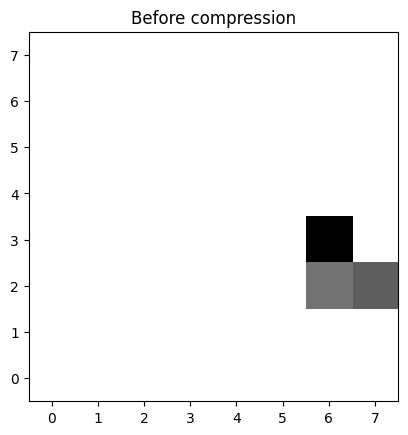

After compression
Shape: (1, 8, 8)


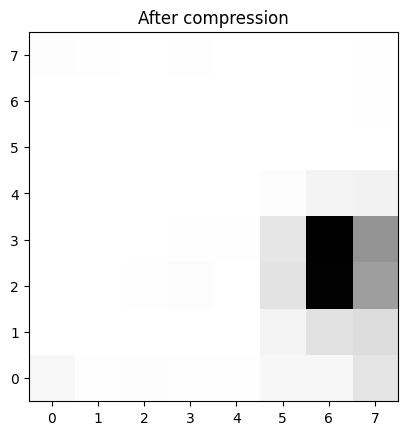

Epoch 2/80: 100%|██████████| 199/199 [00:00<00:00, 529.98it/s, Loss=0.0384]


Epoch [2/80]Average Loss: BCE = 0.0374, MSE = 0.002875966134588772, KL = 2.8856383735810094
Average validation set BCE loss: 0.48748983144760133
Last batch patch, compression metrics:
compression_ratio = 0.5933031350507663
total_hits = 48169
total_hit_bits = 1204225
total_patch_amount = 15857
encoded_patch_bits = 128
total_encoded_patch_bits = 2029696


Epoch 3/80: 100%|██████████| 199/199 [00:00<00:00, 534.88it/s, Loss=0.0265]


Epoch [3/80]Average Loss: BCE = 0.0337, MSE = 0.002325800716661703, KL = 3.0238661047202258
Average validation set BCE loss: 0.36298310875892636
Last batch patch, compression metrics:
compression_ratio = 0.5933031350507663
total_hits = 48169
total_hit_bits = 1204225
total_patch_amount = 15857
encoded_patch_bits = 128
total_encoded_patch_bits = 2029696


Epoch 4/80: 100%|██████████| 199/199 [00:00<00:00, 514.42it/s, Loss=0.0264]


...

Epoch [9/80]Average Loss: BCE = 0.0297, MSE = 0.0015170530354061244, KL = 3.246843951431351
Average validation set BCE loss: 0.2250996059179306
Last batch patch, compression metrics:
compression_ratio = 0.5933031350507663
total_hits = 48169
total_hit_bits = 1204225
total_patch_amount = 15857
encoded_patch_bits = 128
total_encoded_patch_bits = 2029696


Epoch 10/80: 100%|██████████| 199/199 [00:00<00:00, 524.04it/s, Loss=0.0314]


Epoch [10/80]Average Loss: BCE = 0.0294, MSE = 0.0014147056590171354, KL = 3.268254302853915
Average validation set BCE loss: 0.21159057557582855
Last batch patch, compression metrics:
compression_ratio = 0.5933031350507663
total_hits = 48169
total_hit_bits = 1204225
total_patch_amount = 15857
encoded_patch_bits = 128
total_encoded_patch_bits = 2029696


Epoch 11/80: 100%|██████████| 199/199 [00:00<00:00, 528.44it/s, Loss=0.0283]


Epoch [11/80]Average Loss: BCE = 0.0292, MSE = 0.0013579728649858965, KL = 3.281425059141226
Average validation set BCE loss: 0.21070963114500046
Last batch patch, compression metrics:
compression_ratio = 0.5933031350507663
total_hits = 48169
total_hit_bits = 1204225
total_patch_amount = 15857
encoded_patch_bits = 128
total_encoded_patch_bits = 2029696
Last validation batch patch mu and logvar:
mu: mean=-0.0182, std=0.7724 | logvar: mean=-6.9763, std=1.0888
Before compression
Shape: (64, 8, 8)


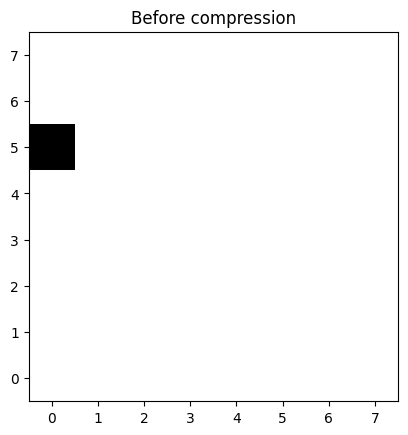

After compression
Shape: (1, 8, 8)


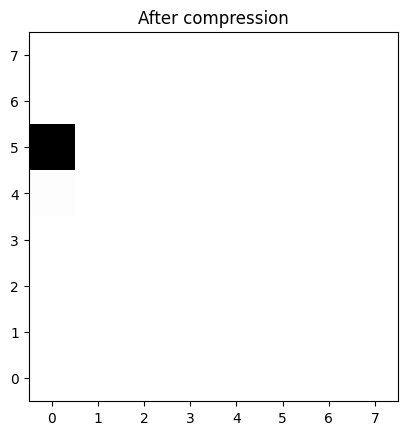

Epoch 12/80: 100%|██████████| 199/199 [00:00<00:00, 526.12it/s, Loss=0.0275]


Epoch [12/80]Average Loss: BCE = 0.0290, MSE = 0.0012874396584562995, KL = 3.298090769417921
Average validation set BCE loss: 0.20576025038957596
Last batch patch, compression metrics:
compression_ratio = 0.5933031350507663
total_hits = 48169
total_hit_bits = 1204225
total_patch_amount = 15857
encoded_patch_bits = 128
total_encoded_patch_bits = 2029696


Epoch 13/80: 100%|██████████| 199/199 [00:00<00:00, 513.38it/s, Loss=0.028] 


Epoch [13/80]Average Loss: BCE = 0.0288, MSE = 0.0012455341387446503, KL = 3.301039323135836
Average validation set BCE loss: 0.19962039232254028
Last batch patch, compression metrics:
compression_ratio = 0.5933031350507663
total_hits = 48169
total_hit_bits = 1204225
total_patch_amount = 15857
encoded_patch_bits = 128
total_encoded_patch_bits = 2029696


Epoch 14/80: 100%|██████████| 199/199 [00:00<00:00, 513.40it/s, Loss=0.0287]


...

Epoch [19/80]Average Loss: BCE = 0.0279, MSE = 0.0009204004902916787, KL = 3.351535030345821
Average validation set BCE loss: 0.18620894759893417
Last batch patch, compression metrics:
compression_ratio = 0.5933031350507663
total_hits = 48169
total_hit_bits = 1204225
total_patch_amount = 15857
encoded_patch_bits = 128
total_encoded_patch_bits = 2029696


Epoch 20/80: 100%|██████████| 199/199 [00:00<00:00, 512.88it/s, Loss=0.0302]


Epoch [20/80]Average Loss: BCE = 0.0278, MSE = 0.0008784413973019276, KL = 3.355544658162486
Average validation set BCE loss: 0.16989057898521423
Last batch patch, compression metrics:
compression_ratio = 0.5933031350507663
total_hits = 48169
total_hit_bits = 1204225
total_patch_amount = 15857
encoded_patch_bits = 128
total_encoded_patch_bits = 2029696


Epoch 21/80: 100%|██████████| 199/199 [00:00<00:00, 514.28it/s, Loss=0.0317]


Epoch [21/80]Average Loss: BCE = 0.0277, MSE = 0.0008225582906246261, KL = 3.358190427473442
Average validation set BCE loss: 0.17483504474163056
Last batch patch, compression metrics:
compression_ratio = 0.5933031350507663
total_hits = 48169
total_hit_bits = 1204225
total_patch_amount = 15857
encoded_patch_bits = 128
total_encoded_patch_bits = 2029696
Last validation batch patch mu and logvar:
mu: mean=-0.0335, std=0.8221 | logvar: mean=-7.0446, std=1.0441
Before compression
Shape: (64, 8, 8)


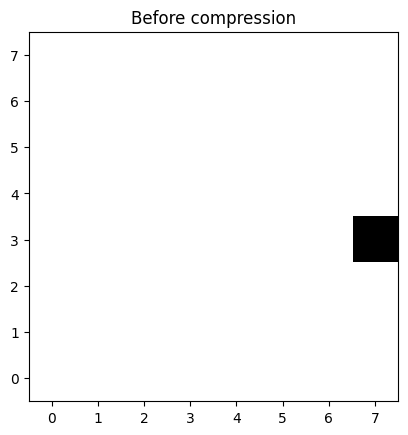

After compression
Shape: (1, 8, 8)


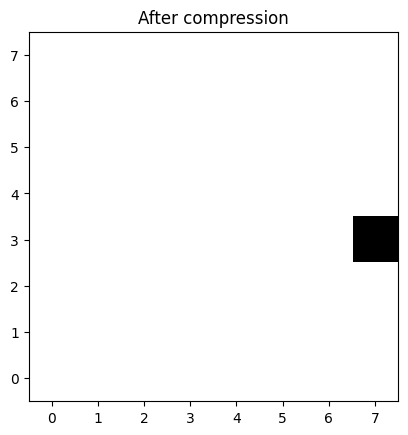

Epoch 22/80: 100%|██████████| 199/199 [00:00<00:00, 513.59it/s, Loss=0.0195]


Epoch [22/80]Average Loss: BCE = 0.0275, MSE = 0.000768621298004803, KL = 3.35308029424006
Average validation set BCE loss: 0.16869228661060334
Last batch patch, compression metrics:
compression_ratio = 0.5933031350507663
total_hits = 48169
total_hit_bits = 1204225
total_patch_amount = 15857
encoded_patch_bits = 128
total_encoded_patch_bits = 2029696


Epoch 23/80: 100%|██████████| 199/199 [00:00<00:00, 510.42it/s, Loss=0.0263]


Epoch [23/80]Average Loss: BCE = 0.0274, MSE = 0.0007346340207366657, KL = 3.361352431714235
Average validation set BCE loss: 0.1731797993183136
Last batch patch, compression metrics:
compression_ratio = 0.5933031350507663
total_hits = 48169
total_hit_bits = 1204225
total_patch_amount = 15857
encoded_patch_bits = 128
total_encoded_patch_bits = 2029696


Epoch 24/80: 100%|██████████| 199/199 [00:00<00:00, 515.03it/s, Loss=0.0257]


...

Epoch [29/80]Average Loss: BCE = 0.0269, MSE = 0.0005799251617764324, KL = 3.3960645546266184
Average validation set BCE loss: 0.16002734124660492
Last batch patch, compression metrics:
compression_ratio = 0.5933031350507663
total_hits = 48169
total_hit_bits = 1204225
total_patch_amount = 15857
encoded_patch_bits = 128
total_encoded_patch_bits = 2029696


Epoch 30/80: 100%|██████████| 199/199 [00:00<00:00, 528.10it/s, Loss=0.0293]


Epoch [30/80]Average Loss: BCE = 0.0269, MSE = 0.0005599988219924927, KL = 3.3975286747342976
Average validation set BCE loss: 0.1561776077747345
Last batch patch, compression metrics:
compression_ratio = 0.5933031350507663
total_hits = 48169
total_hit_bits = 1204225
total_patch_amount = 15857
encoded_patch_bits = 128
total_encoded_patch_bits = 2029696


Epoch 31/80: 100%|██████████| 199/199 [00:00<00:00, 511.90it/s, Loss=0.025] 


Epoch [31/80]Average Loss: BCE = 0.0268, MSE = 0.0005339006750742629, KL = 3.4018810322536295
Average validation set BCE loss: 0.15157612085342406
Last batch patch, compression metrics:
compression_ratio = 0.5933031350507663
total_hits = 48169
total_hit_bits = 1204225
total_patch_amount = 15857
encoded_patch_bits = 128
total_encoded_patch_bits = 2029696
Last validation batch patch mu and logvar:
mu: mean=-0.0200, std=0.8565 | logvar: mean=-7.0789, std=1.0296
Before compression
Shape: (64, 8, 8)


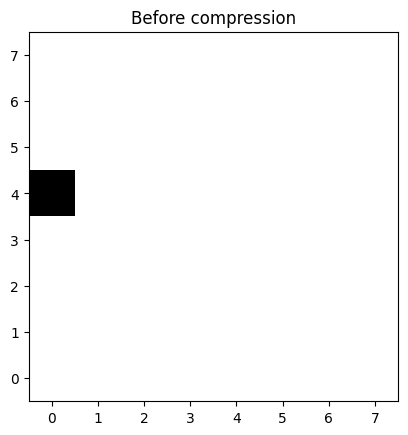

After compression
Shape: (1, 8, 8)


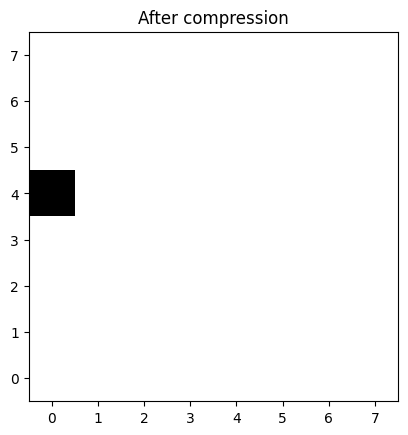

Epoch 32/80: 100%|██████████| 199/199 [00:00<00:00, 504.14it/s, Loss=0.0244]


Epoch [32/80]Average Loss: BCE = 0.0267, MSE = 0.0004866800178690631, KL = 3.4006511302449596
Average validation set BCE loss: 0.1434836858510971
Last batch patch, compression metrics:
compression_ratio = 0.5933031350507663
total_hits = 48169
total_hit_bits = 1204225
total_patch_amount = 15857
encoded_patch_bits = 128
total_encoded_patch_bits = 2029696


Epoch 33/80: 100%|██████████| 199/199 [00:00<00:00, 513.16it/s, Loss=0.0254]


Epoch [33/80]Average Loss: BCE = 0.0266, MSE = 0.0004408053843767836, KL = 3.408342760411938
Average validation set BCE loss: 0.14302683472633362
Last batch patch, compression metrics:
compression_ratio = 0.5933031350507663
total_hits = 48169
total_hit_bits = 1204225
total_patch_amount = 15857
encoded_patch_bits = 128
total_encoded_patch_bits = 2029696


Epoch 34/80: 100%|██████████| 199/199 [00:00<00:00, 513.61it/s, Loss=0.0356]


...

Epoch [39/80]Average Loss: BCE = 0.0261, MSE = 0.0002920193794819915, KL = 3.410785352764417
Average validation set BCE loss: 0.12987481489777564
Last batch patch, compression metrics:
compression_ratio = 0.5933031350507663
total_hits = 48169
total_hit_bits = 1204225
total_patch_amount = 15857
encoded_patch_bits = 128
total_encoded_patch_bits = 2029696


Epoch 40/80: 100%|██████████| 199/199 [00:00<00:00, 508.38it/s, Loss=0.0299]


Epoch [40/80]Average Loss: BCE = 0.0261, MSE = 0.00025693947516894204, KL = 3.408641226926641
Average validation set BCE loss: 0.13010280027985574
Last batch patch, compression metrics:
compression_ratio = 0.5933031350507663
total_hits = 48169
total_hit_bits = 1204225
total_patch_amount = 15857
encoded_patch_bits = 128
total_encoded_patch_bits = 2029696


Epoch 41/80: 100%|██████████| 199/199 [00:00<00:00, 501.97it/s, Loss=0.0264]


Epoch [41/80]Average Loss: BCE = 0.0260, MSE = 0.00021066634544878075, KL = 3.407078152325884
Average validation set BCE loss: 0.12103626370429993
Last batch patch, compression metrics:
compression_ratio = 0.5933031350507663
total_hits = 48169
total_hit_bits = 1204225
total_patch_amount = 15857
encoded_patch_bits = 128
total_encoded_patch_bits = 2029696
Last validation batch patch mu and logvar:
mu: mean=-0.0360, std=0.8694 | logvar: mean=-7.0686, std=1.0356
Before compression
Shape: (64, 8, 8)


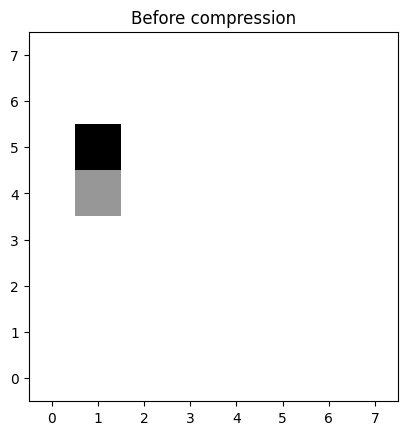

After compression
Shape: (1, 8, 8)


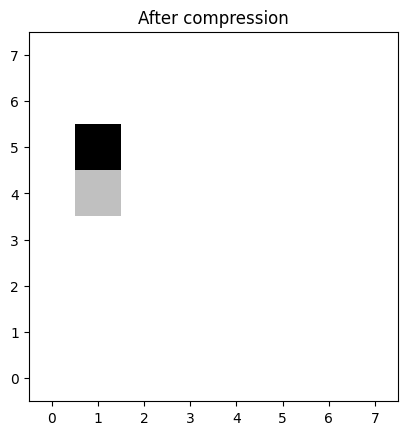

Epoch 42/80: 100%|██████████| 199/199 [00:00<00:00, 512.26it/s, Loss=0.0348]


Epoch [42/80]Average Loss: BCE = 0.0259, MSE = 0.0001830354615699046, KL = 3.4088442673036203
Average validation set BCE loss: 0.11959307730197906
Last batch patch, compression metrics:
compression_ratio = 0.5933031350507663
total_hits = 48169
total_hit_bits = 1204225
total_patch_amount = 15857
encoded_patch_bits = 128
total_encoded_patch_bits = 2029696


Epoch 43/80: 100%|██████████| 199/199 [00:00<00:00, 521.07it/s, Loss=0.0328]


Epoch [43/80]Average Loss: BCE = 0.0258, MSE = 0.00016078040987018018, KL = 3.4098277056037483
Average validation set BCE loss: 0.11926011711359025
Last batch patch, compression metrics:
compression_ratio = 0.5933031350507663
total_hits = 48169
total_hit_bits = 1204225
total_patch_amount = 15857
encoded_patch_bits = 128
total_encoded_patch_bits = 2029696


Epoch 44/80: 100%|██████████| 199/199 [00:00<00:00, 529.01it/s, Loss=0.0244]


...

Epoch [49/80]Average Loss: BCE = 0.0256, MSE = 9.575667153416791e-05, KL = 3.3979537810512523
Average validation set BCE loss: 0.10335273116827011
Last batch patch, compression metrics:
compression_ratio = 0.5933031350507663
total_hits = 48169
total_hit_bits = 1204225
total_patch_amount = 15857
encoded_patch_bits = 128
total_encoded_patch_bits = 2029696


Epoch 50/80: 100%|██████████| 199/199 [00:00<00:00, 514.53it/s, Loss=0.0241]


Epoch [50/80]Average Loss: BCE = 0.0256, MSE = 9.153347963177079e-05, KL = 3.399964991526388
Average validation set BCE loss: 0.09712657377123833
Last batch patch, compression metrics:
compression_ratio = 0.5933031350507663
total_hits = 48169
total_hit_bits = 1204225
total_patch_amount = 15857
encoded_patch_bits = 128
total_encoded_patch_bits = 2029696


Epoch 51/80: 100%|██████████| 199/199 [00:00<00:00, 515.64it/s, Loss=0.0204]


Epoch [51/80]Average Loss: BCE = 0.0255, MSE = 8.813905399953759e-05, KL = 3.397820998675859
Average validation set BCE loss: 0.09949101582169532
Last batch patch, compression metrics:
compression_ratio = 0.5933031350507663
total_hits = 48169
total_hit_bits = 1204225
total_patch_amount = 15857
encoded_patch_bits = 128
total_encoded_patch_bits = 2029696
Last validation batch patch mu and logvar:
mu: mean=-0.0360, std=0.8558 | logvar: mean=-7.0637, std=1.0001
Before compression
Shape: (64, 8, 8)


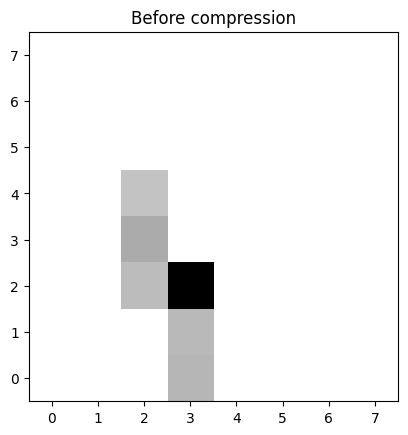

After compression
Shape: (1, 8, 8)


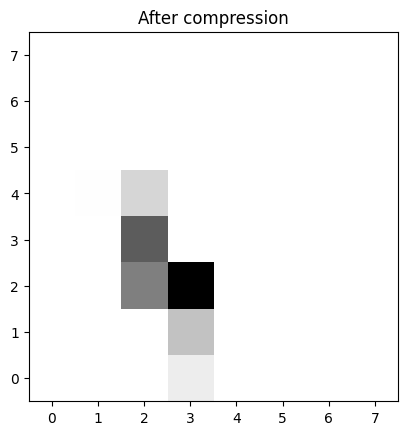

Epoch 52/80: 100%|██████████| 199/199 [00:00<00:00, 506.47it/s, Loss=0.0299]


Epoch [52/80]Average Loss: BCE = 0.0255, MSE = 8.173494937744263e-05, KL = 3.3969062860287615
Average validation set BCE loss: 0.10043722331523895
Last batch patch, compression metrics:
compression_ratio = 0.5933031350507663
total_hits = 48169
total_hit_bits = 1204225
total_patch_amount = 15857
encoded_patch_bits = 128
total_encoded_patch_bits = 2029696


Epoch 53/80: 100%|██████████| 199/199 [00:00<00:00, 531.59it/s, Loss=0.0249]


Epoch [53/80]Average Loss: BCE = 0.0255, MSE = 8.118145772061152e-05, KL = 3.3964121737072817
Average validation set BCE loss: 0.09379950270056725
Last batch patch, compression metrics:
compression_ratio = 0.5933031350507663
total_hits = 48169
total_hit_bits = 1204225
total_patch_amount = 15857
encoded_patch_bits = 128
total_encoded_patch_bits = 2029696


Epoch 54/80: 100%|██████████| 199/199 [00:00<00:00, 525.96it/s, Loss=0.0279]


...

Epoch [59/80]Average Loss: BCE = 0.0255, MSE = 7.138742748153602e-05, KL = 3.3906088019136207
Average validation set BCE loss: 0.09396742254495621
Last batch patch, compression metrics:
compression_ratio = 0.5933031350507663
total_hits = 48169
total_hit_bits = 1204225
total_patch_amount = 15857
encoded_patch_bits = 128
total_encoded_patch_bits = 2029696


Epoch 60/80: 100%|██████████| 199/199 [00:00<00:00, 513.42it/s, Loss=0.0246]


Epoch [60/80]Average Loss: BCE = 0.0254, MSE = 6.613653996607158e-05, KL = 3.3899943217560273
Average validation set BCE loss: 0.09414507403969764
Last batch patch, compression metrics:
compression_ratio = 0.5933031350507663
total_hits = 48169
total_hit_bits = 1204225
total_patch_amount = 15857
encoded_patch_bits = 128
total_encoded_patch_bits = 2029696


Epoch 61/80: 100%|██████████| 199/199 [00:00<00:00, 511.27it/s, Loss=0.0304]


Epoch [61/80]Average Loss: BCE = 0.0255, MSE = 6.734095601205265e-05, KL = 3.389962415599344
Average validation set BCE loss: 0.08772243306040764
Last batch patch, compression metrics:
compression_ratio = 0.5933031350507663
total_hits = 48169
total_hit_bits = 1204225
total_patch_amount = 15857
encoded_patch_bits = 128
total_encoded_patch_bits = 2029696
Last validation batch patch mu and logvar:
mu: mean=-0.0328, std=0.8406 | logvar: mean=-7.0881, std=0.9620
Before compression
Shape: (64, 8, 8)


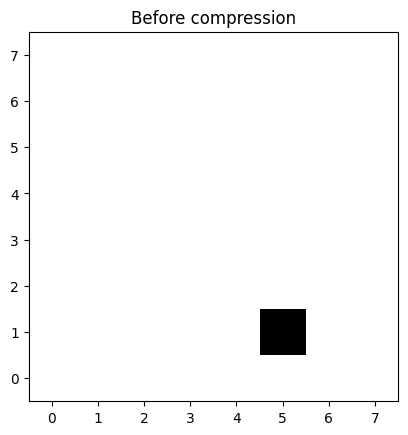

After compression
Shape: (1, 8, 8)


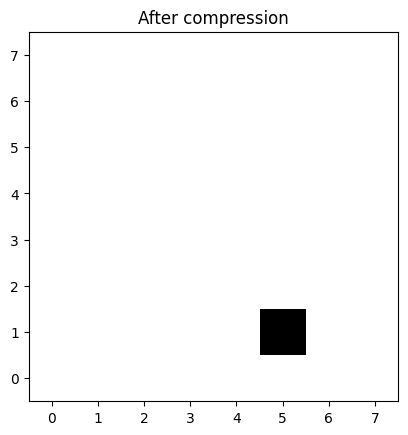

Epoch 62/80: 100%|██████████| 199/199 [00:00<00:00, 500.72it/s, Loss=0.0273]


Epoch [62/80]Average Loss: BCE = 0.0254, MSE = 6.402108723632044e-05, KL = 3.3889596282537258
Average validation set BCE loss: 0.08788327172398568
Last batch patch, compression metrics:
compression_ratio = 0.5933031350507663
total_hits = 48169
total_hit_bits = 1204225
total_patch_amount = 15857
encoded_patch_bits = 128
total_encoded_patch_bits = 2029696


Epoch 63/80: 100%|██████████| 199/199 [00:00<00:00, 511.60it/s, Loss=0.0244]


Epoch [63/80]Average Loss: BCE = 0.0254, MSE = 5.948288851676757e-05, KL = 3.388360164872366
Average validation set BCE loss: 0.0894370660185814
Last batch patch, compression metrics:
compression_ratio = 0.5933031350507663
total_hits = 48169
total_hit_bits = 1204225
total_patch_amount = 15857
encoded_patch_bits = 128
total_encoded_patch_bits = 2029696


Epoch 64/80: 100%|██████████| 199/199 [00:00<00:00, 524.25it/s, Loss=0.0239]


...

Epoch [69/80]Average Loss: BCE = 0.0254, MSE = 5.098859241225548e-05, KL = 3.381937337281117
Average validation set BCE loss: 0.08859257534146309
Last batch patch, compression metrics:
compression_ratio = 0.5933031350507663
total_hits = 48169
total_hit_bits = 1204225
total_patch_amount = 15857
encoded_patch_bits = 128
total_encoded_patch_bits = 2029696


Epoch 70/80: 100%|██████████| 199/199 [00:00<00:00, 539.89it/s, Loss=0.0338]


Epoch [70/80]Average Loss: BCE = 0.0254, MSE = 5.274957373184585e-05, KL = 3.3814482545133813
Average validation set BCE loss: 0.0859285232424736
Last batch patch, compression metrics:
compression_ratio = 0.5933031350507663
total_hits = 48169
total_hit_bits = 1204225
total_patch_amount = 15857
encoded_patch_bits = 128
total_encoded_patch_bits = 2029696


Epoch 71/80: 100%|██████████| 199/199 [00:00<00:00, 510.16it/s, Loss=0.0298]


Epoch [71/80]Average Loss: BCE = 0.0254, MSE = 5.565960676373912e-05, KL = 3.3778006587196234
Average validation set BCE loss: 0.08569361388683319
Last batch patch, compression metrics:
compression_ratio = 0.5933031350507663
total_hits = 48169
total_hit_bits = 1204225
total_patch_amount = 15857
encoded_patch_bits = 128
total_encoded_patch_bits = 2029696
Last validation batch patch mu and logvar:
mu: mean=-0.0380, std=0.8378 | logvar: mean=-7.0716, std=0.9583
Before compression
Shape: (64, 8, 8)


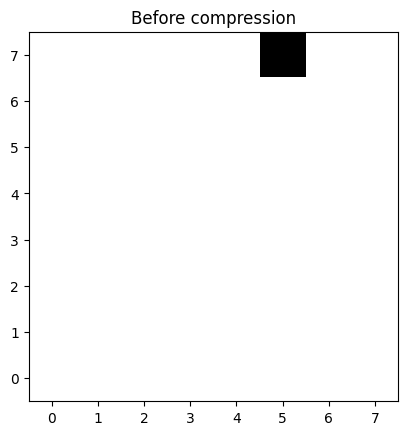

After compression
Shape: (1, 8, 8)


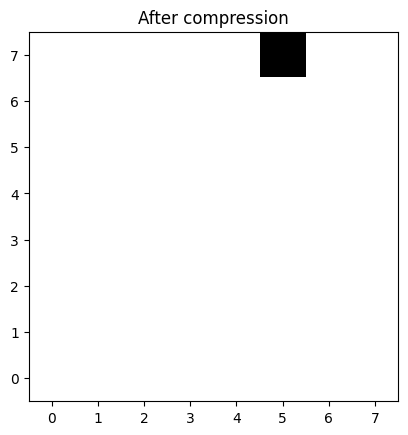

Epoch 72/80: 100%|██████████| 199/199 [00:00<00:00, 518.81it/s, Loss=0.0338]


Epoch [72/80]Average Loss: BCE = 0.0254, MSE = 5.3096163204982855e-05, KL = 3.3747309260631924
Average validation set BCE loss: 0.0852611356973648
Last batch patch, compression metrics:
compression_ratio = 0.5933031350507663
total_hits = 48169
total_hit_bits = 1204225
total_patch_amount = 15857
encoded_patch_bits = 128
total_encoded_patch_bits = 2029696


Epoch 73/80: 100%|██████████| 199/199 [00:00<00:00, 538.10it/s, Loss=0.0277]


Epoch [73/80]Average Loss: BCE = 0.0254, MSE = 5.3220608962837833e-05, KL = 3.3746303277998115
Average validation set BCE loss: 0.08468428716063499
Last batch patch, compression metrics:
compression_ratio = 0.5933031350507663
total_hits = 48169
total_hit_bits = 1204225
total_patch_amount = 15857
encoded_patch_bits = 128
total_encoded_patch_bits = 2029696


Epoch 74/80: 100%|██████████| 199/199 [00:00<00:00, 527.68it/s, Loss=0.022] 


...

Epoch [78/80]Average Loss: BCE = 0.0254, MSE = 5.291233876836779e-05, KL = 3.3702872530299817
Average validation set BCE loss: 0.08348762422800064
Last batch patch, compression metrics:
compression_ratio = 0.5933031350507663
total_hits = 48169
total_hit_bits = 1204225
total_patch_amount = 15857
encoded_patch_bits = 128
total_encoded_patch_bits = 2029696


Epoch 79/80: 100%|██████████| 199/199 [00:00<00:00, 509.52it/s, Loss=0.0195]


Epoch [79/80]Average Loss: BCE = 0.0253, MSE = 5.069528089195078e-05, KL = 3.369454667795843
Average validation set BCE loss: 0.0823160757124424
Last batch patch, compression metrics:
compression_ratio = 0.5933031350507663
total_hits = 48169
total_hit_bits = 1204225
total_patch_amount = 15857
encoded_patch_bits = 128
total_encoded_patch_bits = 2029696


Epoch 80/80: 100%|██████████| 199/199 [00:00<00:00, 515.95it/s, Loss=0.0359]


Epoch [80/80]Average Loss: BCE = 0.0254, MSE = 4.434357586104116e-05, KL = 3.3663772913678804
Average validation set BCE loss: 0.08448462218046188
Last batch patch, compression metrics:
compression_ratio = 0.5933031350507663
total_hits = 48169
total_hit_bits = 1204225
total_patch_amount = 15857
encoded_patch_bits = 128
total_encoded_patch_bits = 2029696
Saving trained model VAE


In [19]:
# BCE loss average values
average_loss_train = []
average_loss_values_val = []
average_loss_kl_loss = []

# Patches
patches_before = []
patches_after = []
patches_z = [] # latent vector

# MSE residual averages
average_loss_train_mse = []
average_loss_valid_mse = []

plot_val_patches_limit = 30
plot_idx = 0

model.train()

for epoch in range(num_epochs):
    train_loss = 0
    train_loss_mse = 0
    kl_loss_total = 0
    
    progress_bar = tqdm(
        enumerate(train_loader),
        total=len(train_loader),
        desc=f'Epoch {epoch+1}/{num_epochs}'
    )
    
    for (batch_idx, X_adcs) in progress_bar:
        optimizer.zero_grad()
        
        X_adcs = X_adcs.float()
        X_adcs = X_adcs.to(device)
        
        (
            recon_patch, 
            mu,
            logvar,
            _
        ) = model(
           X_adcs
        )
        
        loss, recon_loss, beta, kl_loss = _get_vae_loss(recon_patch, X_adcs, mu, logvar)
        
        recon_patch = recon_patch.float().to(device)      
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5)
        
        train_loss += loss.item()
        kl_loss_total += kl_loss.item()
        
        train_loss_mse += mse(recon_patch, X_adcs).item()
        
        optimizer.step()        

        # Update tqdm description with current loss
        progress_bar.set_postfix({'Loss': loss.item()})
        # scheduler.step()
        
        
    avg_loss_bce = train_loss / len(train_loader)
    avg_loss_mse = train_loss_mse / len(train_loader)
    avg_loss_kl = kl_loss_total / len(train_loader)
    
    print(
        f"Epoch [{epoch + 1}/{num_epochs}]"
        f"Average Loss: BCE = {avg_loss_bce:.4f}, "
        f"MSE = {avg_loss_mse}, " 
        f"KL = {avg_loss_kl}"
    )
    
    average_loss_train.append(avg_loss_bce)
    average_loss_train_mse.append(avg_loss_mse)
    average_loss_kl_loss.append(avg_loss_kl)
    
    # Test with validation set for checking error residuals
    with torch.no_grad():
        model.eval()
        total_bce_loss = 0
        total_mse_loss = 0
        
        for patch_val in val_loader:
            patch_val = patch_val.to(device)  
            
            (
                recon_patch, 
                mu,
                logvar, 
                z 
            ) = model(patch_val)
            
            total_bce_loss += F.binary_cross_entropy(
                patch_val,
                recon_patch,
                reduction="mean"
            ).cpu().detach().numpy().item()
            
            total_mse_loss += mse(
               patch_val,
               recon_patch  
            ).item()
            
            result = _get_compression_ratio_vae(
                total_hit_amount, 
                patch_amount,
                z
            )
        
        average_loss_val = total_bce_loss / len(val_loader)
        average_loss_val_mse = total_mse_loss / len(val_loader)
        average_loss_values_val.append(average_loss_val)
        average_loss_valid_mse.append(average_loss_val_mse)
        
        print(f"Average validation set BCE loss: {average_loss_val}")
        print("Last batch patch, compression metrics:")
        for k, v in result.items():
            print(f"{k} = {v}")
    
        # Test with validation set for checking image reconstruction quality
    
        if epoch % LOG_EVERY == 0:
                # selecting events before reconstruction using one test loader as validation
                
                patches_pairs = []
                
                for patch_val in val_loader:
                    patch_val = patch_val.to(device)           
                    
                    (
                        recon_patch, 
                        mu,
                        logvar, 
                        z
                    ) = model(patch_val)
                    
                    if len(patches_pairs) < plot_val_patches_limit:
                        patches_pairs.append((patch_val, z, recon_patch))
                
                print("Last validation batch patch mu and logvar:")
                print(
                    f"mu: mean={mu.mean().item():.4f}, std={mu.std().item():.4f} | "
                    f"logvar: mean={logvar.mean().item():.4f}, std={logvar.std().item():.4f}"
                )
                # print("Loss statistics:")
                # print(
                #     f"recon={recon_loss.item():.4f}, "
                #     f"kl={kl_loss.item():.4f}, " if beta > 0 else ""
                #     f"beta_kl={(beta * kl_loss).item():.4f}" if beta > 0 else ""
                # )
                
                if plot_idx < len(patches_pairs):
                    patch_val_before, z, patch_val_after = patches_pairs[plot_idx]
                    
                    print("Before compression")                    
                    patch_val_ts = _tensor_to_numpy(
                        patch_val_before.squeeze(1)
                    )
                    
                    print(f"Shape: {patch_val_ts.shape}")            
                    plot_patch(patch_val_ts[0], "Before compression")
                    
                    patches_before.append(patch_val_ts[0])
                    
                    recon_patch_np = _tensor_to_numpy(
                        patch_val_after[0]
                    )
                    print("After compression")
                    print(f"Shape: {recon_patch_np.shape}")
                    
                    plot_patch(recon_patch_np[0], "After compression")
                
                    patches_after.append(recon_patch_np[0])  
                    z_np = _tensor_to_numpy(z[0][0])
                    patches_z.append(z_np) 
                    
                    plot_idx += 1        
            
# save model
print("Saving trained model VAE")
torch.save(model.state_dict(), "vae.pth")

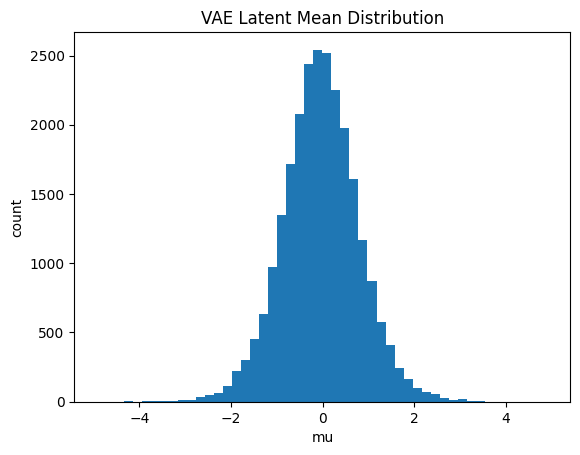

In [20]:
mu_values = mu.detach().cpu().flatten().numpy()
# histogram
plt.hist(mu_values, bins=50)

plt.title("VAE Latent Mean Distribution")
plt.xlabel("mu")
plt.ylabel("count")

plt.show()

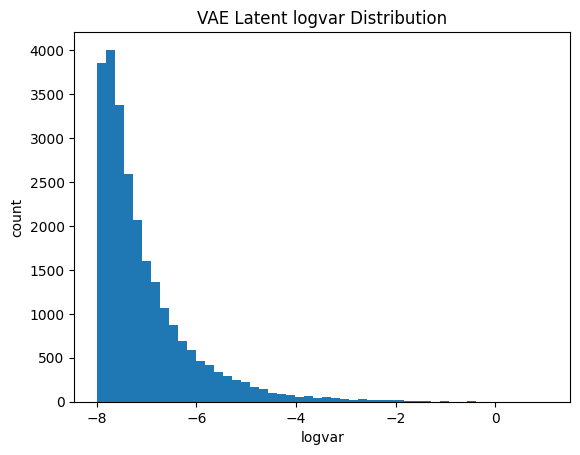

In [21]:
logvar_values = logvar.detach().cpu().flatten().numpy()
# histogram
plt.hist(logvar_values, bins=50)

plt.title("VAE Latent logvar Distribution")
plt.xlabel("logvar")
plt.ylabel("count")

plt.show()

In [22]:
# TODO
# Compression ratio calculation
# Find total sum of hit bits
# Find total sum of encoded patch bits

total_bits = _get_total_hit_bits(total_hit_amount)


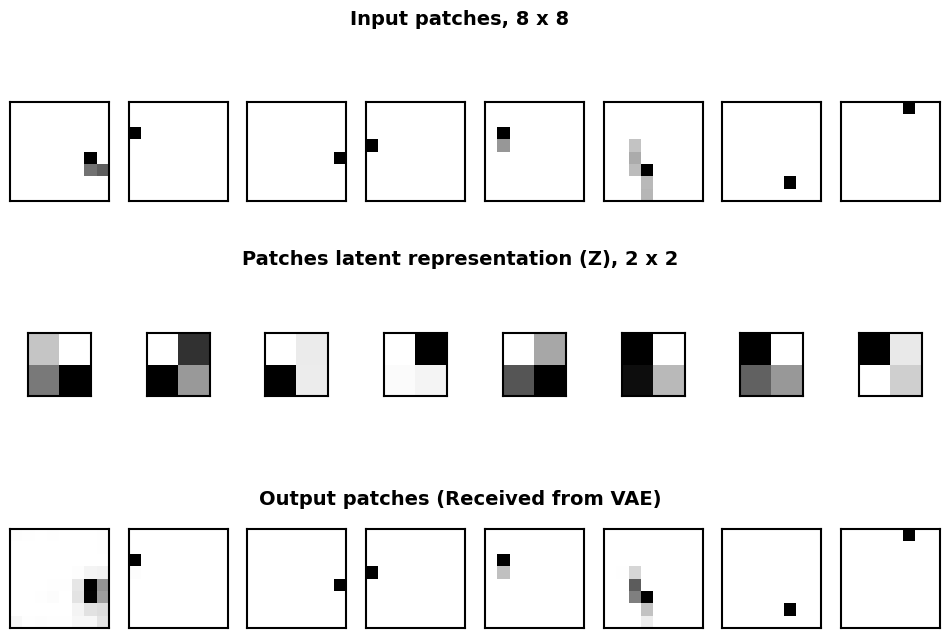

In [23]:
def plot_patches(patch_rows: list[tuple]) -> None:
    cols = len(patch_rows[0][0])
    rows = len(patch_rows)

    # fig, axes = plt.subplots(rows, cols, figsize=(12, 6))
    fig = plt.figure(figsize=(12, 8))
    gs = GridSpec(
        3, cols,
        height_ratios=[1.5, 0.5, 1.5]
    )

    for i in range(rows):
        
        (patch_row, patch_row_title) = patch_rows[i]
        
        fig.text(
            0.5,                    # centered horizontally
            0.92 - i * 0.30,        # vertical position
            patch_row_title,
            ha='center',
            fontsize=14,
            fontweight='bold'
        )
        
        for j in range(cols):
            ax = fig.add_subplot(gs[i, j])
            
            ax.imshow(patch_row[j], cmap='gist_yarg', origin='lower')
            
            ax.set_xticks([])
            ax.set_yticks([])
            
            for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_linewidth(1.5)

        plt.subplots_adjust(wspace=0.2, hspace=0.6)
    plt.show()
        
        
patch_rows = [
    (patches_before, "Input patches, 8 x 8"),
    (patches_z, "Patches latent representation (Z), 2 x 2"),
    (patches_after, "Output patches (Received from VAE)")
]

plot_patches(patch_rows)

In [24]:
len(patch_rows[0][0])

8

In [25]:
# TODO
# Improve gradients
_display_gradients(model)

Showing model gradients
encoder.0.weight 0.02422860451042652
encoder.1.weight 0.0008757313480600715
encoder.1.bias 0.0007878997712396085
encoder.3.weight 0.005037001334130764
encoder.4.weight 0.0004491755971685052
encoder.4.bias 0.00033441948471590877
encoder.6.weight 0.005745704285800457
encoder.7.weight 0.000499012996442616
encoder.7.bias 0.0004339754523243755
fc_mean.weight 0.0030045548919588327
fc_mean.bias 0.0003320376854389906
fc_log_var.weight 7.058048504404724e-05
fc_log_var.bias 8.260030881501734e-06
decoder.0.weight 0.004774394910782576
decoder.1.weight 0.000532938982360065
decoder.1.bias 0.00044915906619280577
decoder.3.weight 0.011226365342736244
decoder.4.weight 0.0004562821122817695
decoder.4.bias 0.00046909318189136684
decoder.6.weight 0.0039401547983288765


VAE, Average loss values over epochs


/tmp/ipykernel_443809/3472732.py:79: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


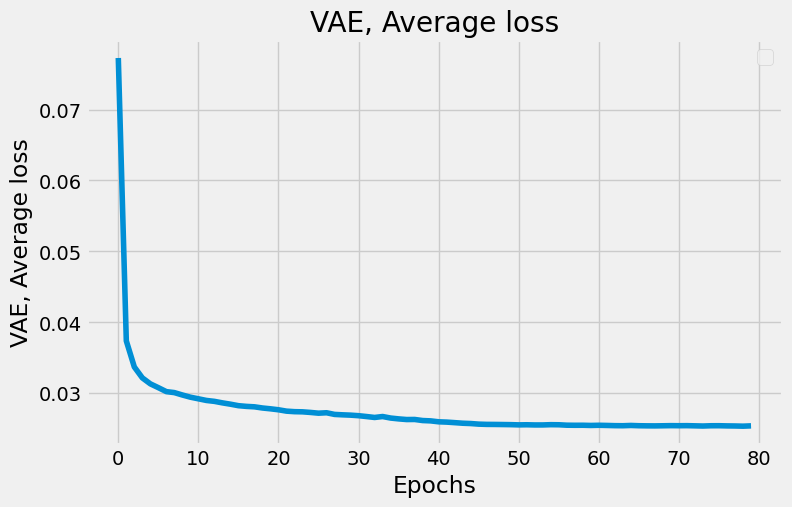

Saving VAE loss values to csv
Saved VAE loss data to csv file


In [26]:
# display loss values
plot_metric_results(
    y_values=average_loss_train, 
    x_values=list(range(num_epochs)),
    y_title="VAE, Average loss",
    title="VAE, Average loss",
    x_label="Epochs"
)

print("Saving VAE loss values to csv")

vae_loss_average_df = pd.DataFrame( 
   {
        "bce_average_train_loss" : average_loss_train,
        "mse_average_train_loss" : average_loss_train_mse,
        "epochs" : list(range(num_epochs))
   }
)
vae_loss_average_df.to_csv("vae_average_train_loss.csv", index=False)

vae_loss_average_df = pd.DataFrame( 
   {
        "bce_average_val_loss" : average_loss_values_val,
        "mse_average_val_loss" : average_loss_valid_mse,
        "epochs" : list(range(num_epochs))
   }
)
vae_loss_average_df.to_csv("vae_average_val_loss.csv", index=False)

print("Saved VAE loss data to csv file")

In [27]:
print(f"mu = {model.z_log_mean.mean().item()}")
print(f"logvar = {model.z_log_var.std().item()}")

mu = -0.038938842713832855
logvar = 0.9640136361122131


In [28]:
# Test set for testing using unseen data
model.load_state_dict(torch.load("vae.pth"))
model.eval()

bce_loss_values_test = []

patch_display_limit = 8
patches_after_test = []
patches_before_test = []
patches_z = [] # latent vector

bce_total_value = 0

test_set_size = len(test_loader)

for patch_test in test_loader:
    patch_test = patch_test.to(device)                     
    (
        recon_patch, 
        mu,
        logvar,
        z
    ) = model(patch_test)
    
    if len(patches_after_test) < patch_display_limit:
        patch_test_np = patch_test[0][0].cpu().detach().numpy()
        patches_before_test.append(patch_test_np)
        
        recon_patch_np = recon_patch[0][0].cpu().detach().numpy()
        patches_after_test.append(recon_patch_np)
        z_np = _tensor_to_numpy(z[0][0])
        
        patches_z.append(z_np)
    
    # mse_loss = F.mse_loss(patch_test, recon_patch).item()
    bce_loss = F.binary_cross_entropy(
        patch_test, 
        recon_patch, 
        reduction="mean"
    ).cpu().detach().numpy().item()
    
    bce_total_value += bce_loss
    
bce_loss_average = bce_total_value / test_set_size

print(f"Based on test set (size = {test_set_size}), average BCE loss = {bce_loss_average:.5f}")

test_df_frame = pd.DataFrame(
    {
        "average_bce_loss_test" : [bce_loss_average],
    }
)
test_df_frame.to_csv("vae_test_loss.csv")

Based on test set (size = 25), average BCE loss = 0.06274


In [29]:
len(patches_before_test)

8

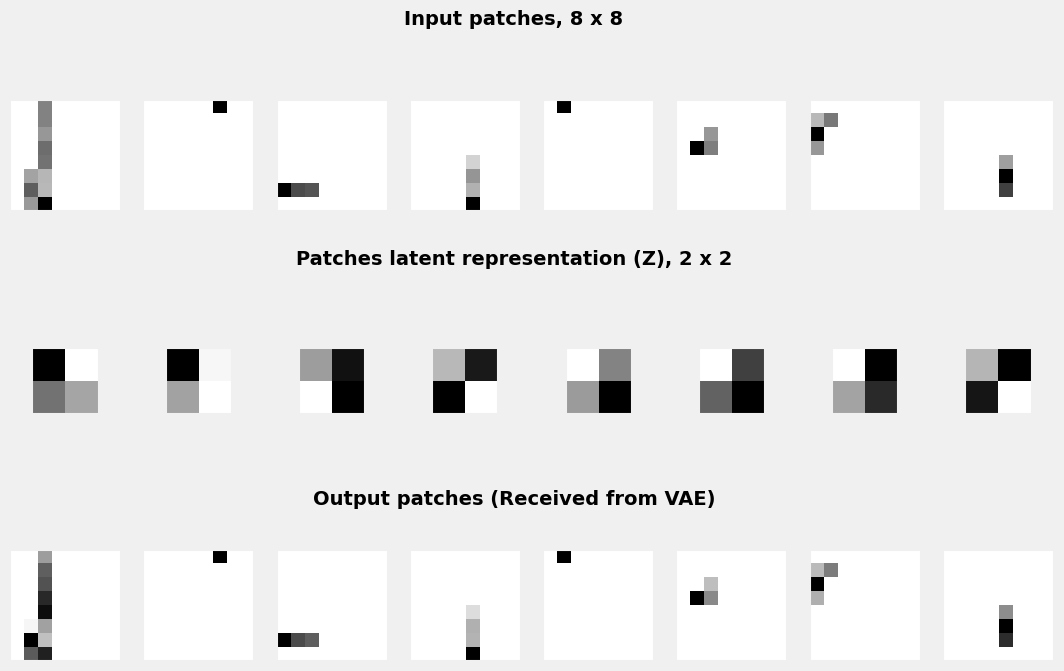

In [30]:
# Test dataset plotting part
patch_rows = [
    (patches_before_test, "Input patches, 8 x 8"),
    (patches_z, "Patches latent representation (Z), 2 x 2"),
    (patches_after_test, "Output patches (Received from VAE)")
]

plot_patches(patch_rows)

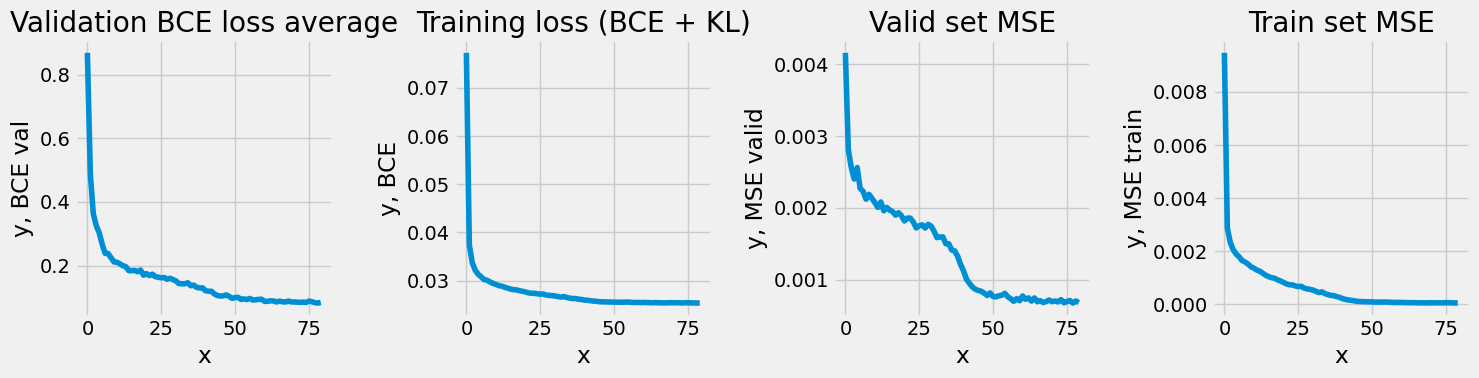

In [31]:
values_to_plot = [
    (list(range(len(average_loss_values_val))), average_loss_values_val, "Validation BCE loss average", "BCE val"),
    (list(range(len(average_loss_train))), average_loss_train, "Training loss (BCE + KL)", "BCE"),
    (list(range(len(average_loss_valid_mse))), average_loss_valid_mse, "Valid set MSE", "MSE valid"),
    (list(range(len(average_loss_train_mse))), average_loss_train_mse, "Train set MSE", "MSE train"),
]

fig, axes = plt.subplots(1, len(values_to_plot), figsize=(15, 4))

for i, (x, y, title, y_label) in enumerate(values_to_plot):
    axes[i].plot(
        x,
        y,
    )
    axes[i].grid(True)
    axes[i].set_title(title)
    axes[i].set_xlabel("x")
    axes[i].set_ylabel(f"y, {y_label}")
    
    for spine in axes[i].spines.values():
        spine.set_linewidth(2)

plt.tight_layout()
plt.show()

# print(title + " values over epochs")
# plt.style.use('fivethirtyeight')
# plt.figure(figsize=(8, 5))
# plt.plot(x_values, y_values, marker=marker)
# plt.xlabel(x_label)
# plt.ylabel(y_title)
# plt.legend()
# plt.title(title)
# plt.show()

In [32]:
average_loss_val_mse

0.0006821765692438931

Comments
* Based on the current results,
the closer the Z latent space values are to the prior (Normal distribution),
the less stable VAE model becomes

* The more KL divergence increases, the reconstruction quality significantly drops

* If the reconstruction quality improves, z distribution becomes almost like gaussian and loss function starts to slow down after 5 epochs

* If 10 and -10 extreme values dissapear, then loss does not fall to quickly and reconstruction quality improves

* 10 and -10 extreme values appear due to high learning rate. Lerning_rate = 1e-2

* Since KL divergence is constantly growing, very small beta (scale factor) is required for the KL divergence

* Increase of latent space and hidden dimensions, marginally improved loss function

* Used 0001.root file pixel digi events for forming test, train and validation sets

* Add atleast 1 padding in network layers for preserving signal

* 1 encoded patch latent vector has size 128bits 4 bytes * 4 bytes * 8 bits 

Comment:
Need to use bigger latent dimension. Bigger than 16. Wider latent dimension,
the more information is preserved after matrix transformations
If latent dimension = 16, than noisy outputs from encoder